# Word Embedding Explorer
Finds nearest neighbours for query terms and visualises the results three ways:
1. **Bar chart** – similarity scores per term  
2. **Scatter plot** – PCA projection of query + neighbour vectors  
3. **Network graph** – relationship graph weighted by similarity

In [1]:
!pip install gensim pandas matplotlib networkx scikit-learn adjustText

In [7]:
import matplotlib.font_manager as _fm
import warnings as _warnings

def _find_cjk_font():
    """Return the first available CJK-capable font name, or None."""
    candidates = [
        "Noto Sans CJK SC", "Noto Sans CJK TC",
        "WenQuanYi Micro Hei", "WenQuanYi Zen Hei",
        "Source Han Sans CN", "Source Han Sans TW",
        "SimHei", "SimSun", "Microsoft YaHei",
        "PingFang SC", "Hiragino Sans GB",
        "Arial Unicode MS", "DejaVu Sans",
    ]
    available = {f.name for f in _fm.fontManager.ttflist}
    for name in candidates:
        if name in available:
            return name
    return None

_cjk_font = _find_cjk_font()
if _cjk_font is None:
    _warnings.warn(
        "No CJK font found — Chinese characters may render as boxes. "
        "Install Noto Sans CJK (e.g. `sudo apt install fonts-noto-cjk`) "
        "then run `import matplotlib; matplotlib.font_manager._load_fontmanager(try_read_cache=False)`.",
        UserWarning,
    )

# from gensim.models import KeyedVectors
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import networkx as nx
from sklearn.decomposition import PCA
from adjustText import adjust_text

# ── aesthetics ────────────────────────────────────────────────────────────────
plt.rcParams.update({
    "figure.facecolor": "#0d1117",
    "axes.facecolor":   "#161b22",
    "axes.edgecolor":   "#30363d",
    "axes.labelcolor":  "#c9d1d9",
    "xtick.color":      "#8b949e",
    "ytick.color":      "#8b949e",
    "text.color":       "#c9d1d9",
    "grid.color":       "#21262d",
    "grid.linewidth":   0.6,
    "font.family":      "sans-serif",
    "font.sans-serif":  ["Noto Sans CJK SC", "WenQuanYi Micro Hei",
                         "Source Han Sans CN", "SimHei", "Arial Unicode MS",
                         "DejaVu Sans", "sans-serif"],
    "axes.titleweight": "bold",
})

PALETTE = ["#58a6ff", "#f78166", "#56d364", "#e3b341", "#bc8cff"]

# ── load model ────────────────────────────────────────────────────────────────
# model = KeyedVectors.load_word2vec_format("embeddings.bin", binary=True)
# For fastText: 
from gensim.models.fasttext import load_facebook_vectors
model = load_facebook_vectors("enp_embeddings/Shunpao/shunpao_300.bin")

query_terms = [
    "留美",
    "留學",
    "遊美",
]

TOPN = 20

# ── collect results ───────────────────────────────────────────────────────────
rows = []
for term in query_terms:
    if term not in model:
        rows.append({"query_term": term, "similar_term": None,
                     "similarity": None, "note": "term not in vocabulary"})
        continue
    for sim_term, score in model.most_similar(term, topn=TOPN):
        rows.append({"query_term": term, "similar_term": sim_term,
                     "similarity": score, "note": ""})

df = pd.DataFrame(rows)
df.to_csv("expanded_queries.csv", index=False, encoding="utf-8-sig")
print(df.to_string(index=False))

query_term similar_term  similarity note
        留美         留美學生    0.713006     
        留美          留美生    0.697571     
        留美         留美大學    0.673395     
        留美         留美碩士    0.667989     
        留美         歐美學生    0.662810     
        留美          美學生    0.661857     
        留美          留美江    0.659519     
        留美         遊美學生    0.648579     
        留美         留美學界    0.631295     
        留美        留美公費生    0.629916     
        留美         游美學生    0.626720     
        留美        美國留學生    0.626453     
        留美         留美牙科    0.623529     
        留美        密希根大學    0.622888     
        留美        留美學生會    0.621088     
        留美      美國華盛頓大學    0.615730     
        留美         老留學生    0.612070     
        留美        哥敦根大學    0.611471     
        留美         留美華僑    0.610022     
        留美       美華盛頓大學    0.609377     
        留學           游學    0.807625     
        留學          留學生    0.757372     
        留學           遊學    0.745259     
        留學      

## Visualisation 1 — Similarity Bar Charts
One subplot per query term, bars ranked by cosine similarity.

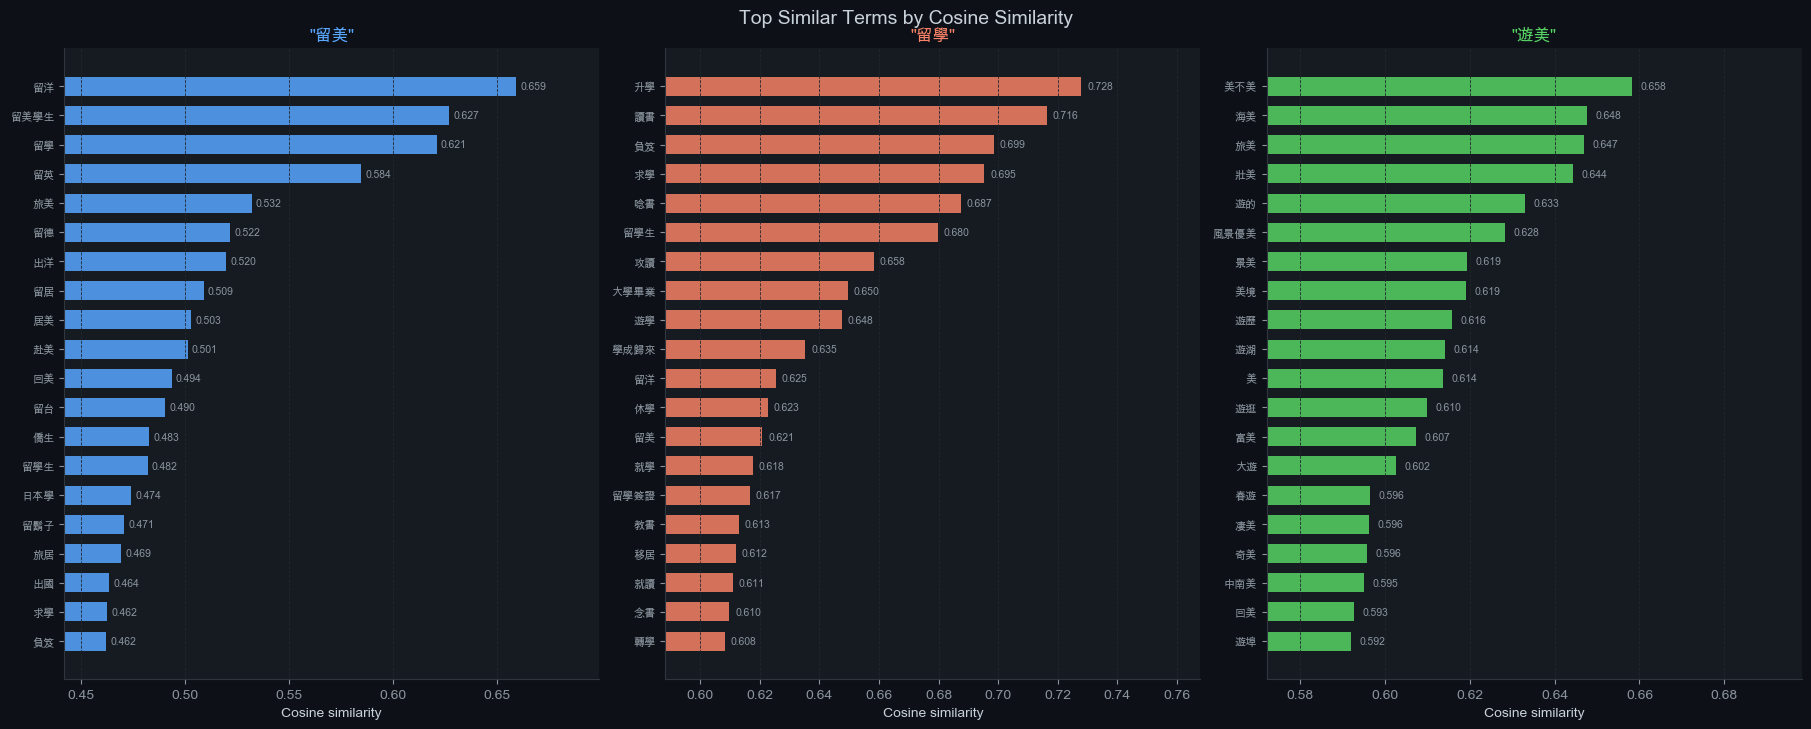

Saved → viz1_bar_charts.png


In [3]:
valid_terms = [t for t in query_terms if t in model]
ncols = len(valid_terms)

fig, axes = plt.subplots(1, ncols, figsize=(6 * ncols, 7),
                         sharey=False, constrained_layout=True)
fig.suptitle("Top Similar Terms by Cosine Similarity", fontsize=14, y=1.02)

if ncols == 1:
    axes = [axes]

for ax, term, color in zip(axes, valid_terms, PALETTE):
    subset = df[df["query_term"] == term].dropna(subset=["similarity"])
    subset = subset.sort_values("similarity", ascending=True)  # ascending so highest is at top

    bars = ax.barh(subset["similar_term"], subset["similarity"],
                   color=color, alpha=0.85, height=0.65)

    # value labels
    for bar, val in zip(bars, subset["similarity"]):
        ax.text(bar.get_width() + 0.002, bar.get_y() + bar.get_height() / 2,
                f"{val:.3f}", va="center", ha="left",
                fontsize=7.5, color="#8b949e")

    ax.set_title(f'"{term}"', color=color, fontsize=12)
    ax.set_xlabel("Cosine similarity")
    ax.set_xlim(subset["similarity"].min() - 0.02,
                subset["similarity"].max() + 0.04)
    ax.grid(axis="x", linestyle="--")
    ax.tick_params(axis="y", labelsize=8)
    ax.spines[["top", "right"]].set_visible(False)

plt.savefig("viz1_bar_charts.png", dpi=150, bbox_inches="tight",
            facecolor=fig.get_facecolor())
plt.show()
print("Saved → viz1_bar_charts.png")

## Visualisation 2 — PCA Scatter Plot
Projects high-dimensional vectors down to 2-D with PCA.  
Query terms are shown as large filled markers; their neighbours as smaller ones, colour-coded by query.

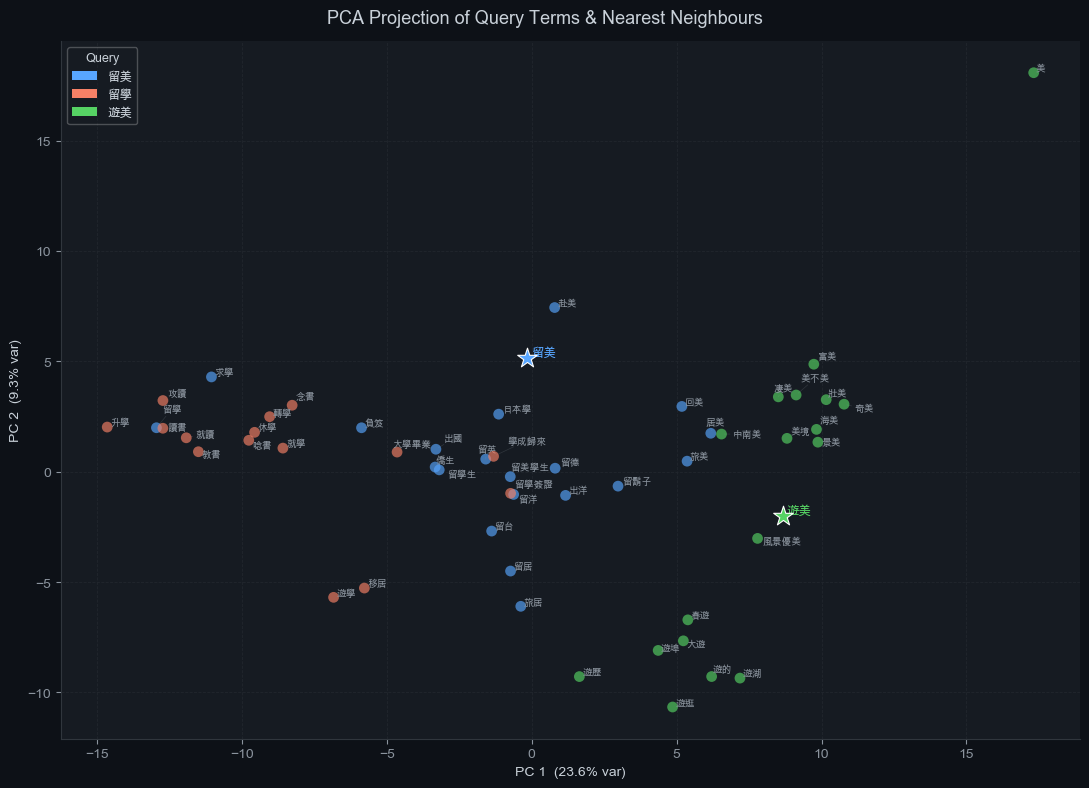

Saved → viz2_pca_scatter.png


In [4]:
# collect all words to project
all_words, word_meta = [], {}   # meta: {word: {"query": str, "is_query": bool}}
for term in valid_terms:
    if term not in all_words:
        all_words.append(term)
        word_meta[term] = {"query": term, "is_query": True}
    for sim_term, _ in model.most_similar(term, topn=TOPN):
        if sim_term not in word_meta:
            all_words.append(sim_term)
            word_meta[sim_term] = {"query": term, "is_query": False}

# stack vectors, run PCA
vectors = np.vstack([model[w] for w in all_words])
pca = PCA(n_components=2, random_state=42)
coords = pca.fit_transform(vectors)
var = pca.explained_variance_ratio_ * 100

fig, ax = plt.subplots(figsize=(11, 8))
fig.suptitle("PCA Projection of Query Terms & Nearest Neighbours", fontsize=13)

texts = []
for i, word in enumerate(all_words):
    meta = word_meta[word]
    q_idx = valid_terms.index(meta["query"])
    color = PALETTE[q_idx]
    is_q = meta["is_query"]

    ax.scatter(coords[i, 0], coords[i, 1],
               c=color, s=220 if is_q else 60,
               marker="*" if is_q else "o",
               zorder=4 if is_q else 3,
               alpha=1.0 if is_q else 0.65,
               edgecolors="#ffffff" if is_q else "none",
               linewidths=0.8)

    fontsize = 9 if is_q else 7
    weight = "bold" if is_q else "normal"
    texts.append(ax.text(coords[i, 0], coords[i, 1], word,
                         fontsize=fontsize, fontweight=weight,
                         color=color if is_q else "#8b949e"))

# repel overlapping labels
adjust_text(texts, ax=ax, arrowprops=dict(arrowstyle="-", color="#30363d", lw=0.5))

legend_handles = [mpatches.Patch(facecolor=PALETTE[i], label=t)
                  for i, t in enumerate(valid_terms)]
ax.legend(handles=legend_handles, title="Query", loc="upper left",
          framealpha=0.3, fontsize=9, title_fontsize=9)

ax.set_xlabel(f"PC 1  ({var[0]:.1f}% var)")
ax.set_ylabel(f"PC 2  ({var[1]:.1f}% var)")
ax.grid(True, linestyle="--")
ax.spines[["top", "right"]].set_visible(False)

plt.tight_layout()
plt.savefig("viz2_pca_scatter.png", dpi=150, bbox_inches="tight",
            facecolor=fig.get_facecolor())
plt.show()
print("Saved → viz2_pca_scatter.png")

## Visualisation 3 — Similarity Network Graph
Each query term is the hub; edges connect it to neighbours with thickness and opacity scaled by similarity score.  
Shared neighbours (words appearing near multiple queries) naturally emerge as cross-cluster bridges.

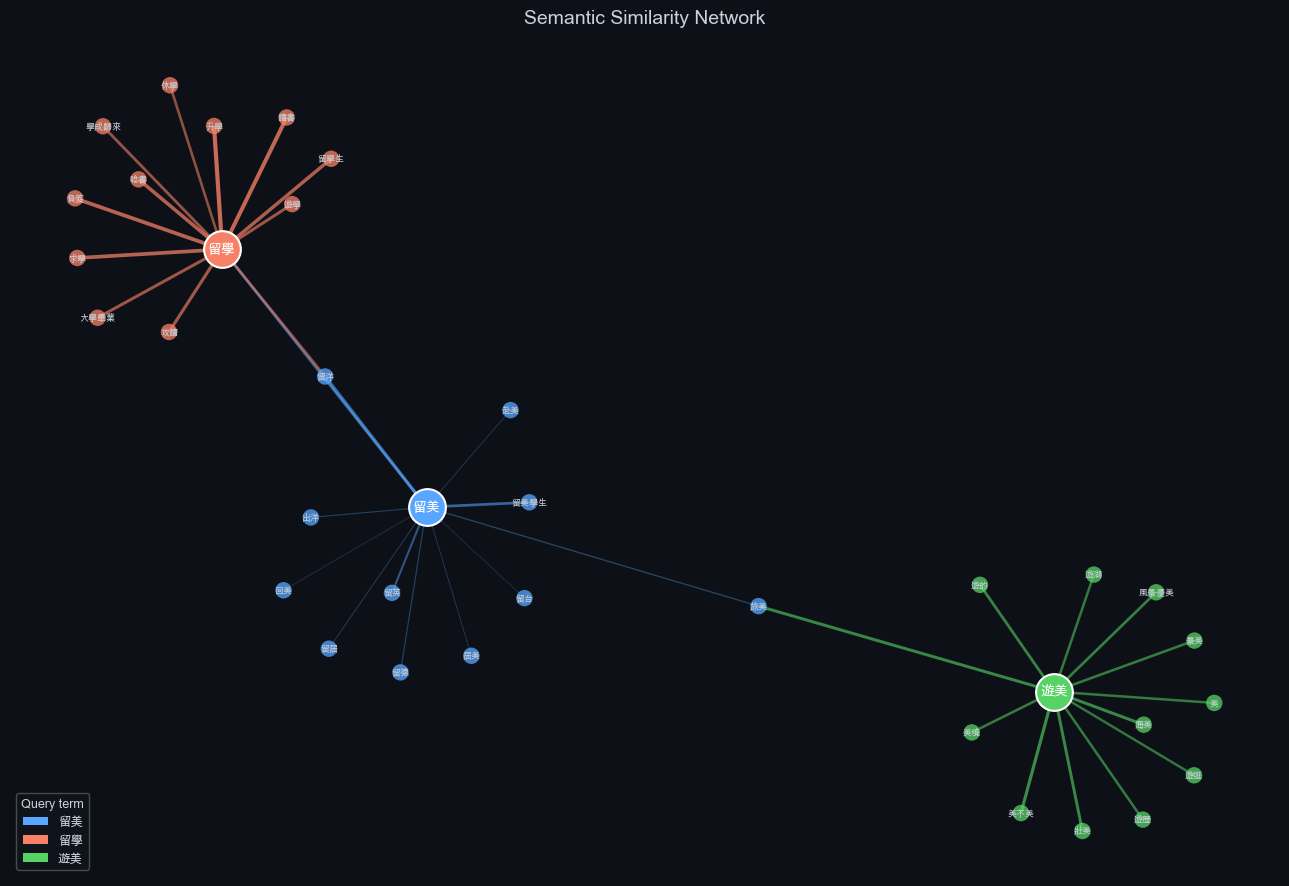

Saved → viz3_network_graph.png


In [5]:
# ── build graph ───────────────────────────────────────────────────────────────
# Use top-N neighbours; use fewer for a cleaner graph
GRAPH_TOPN = 12

G = nx.Graph()
edge_attrs = {}  # (u,v) -> {weight, color}

for term, color in zip(valid_terms, PALETTE):
    G.add_node(term, kind="query", query=term, color=color)
    for sim_term, score in model.most_similar(term, topn=GRAPH_TOPN):
        if not G.has_node(sim_term):
            G.add_node(sim_term, kind="neighbor", query=term,
                       color=PALETTE[valid_terms.index(term)])
        G.add_edge(term, sim_term, weight=score, query=term, color=color)

# ── layout ────────────────────────────────────────────────────────────────────
# Seed for reproducibility; spring layout with high k spreads nodes nicely
pos = nx.spring_layout(G, seed=7, k=2.8 / np.sqrt(G.number_of_nodes()),
                       iterations=120, weight="weight")

# ── draw ──────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(13, 9))
fig.suptitle("Semantic Similarity Network", fontsize=14)

# edges: colour by query term, thickness / alpha by weight
weights = [G[u][v]["weight"] for u, v in G.edges()]
w_arr = np.array(weights)
norm_w = (w_arr - w_arr.min()) / (w_arr.max() - w_arr.min() + 1e-9)

for (u, v), nw, w in zip(G.edges(), norm_w, weights):
    ec = G[u][v]["color"]
    nx.draw_networkx_edges(G, pos, edgelist=[(u, v)], ax=ax,
                           width=0.5 + 2.5 * nw,
                           alpha=0.25 + 0.55 * nw,
                           edge_color=[ec])

# neighbour nodes
nbr_nodes = [n for n, d in G.nodes(data=True) if d["kind"] == "neighbor"]
nbr_colors = [G.nodes[n]["color"] for n in nbr_nodes]
nx.draw_networkx_nodes(G, pos, nodelist=nbr_nodes, ax=ax,
                       node_color=nbr_colors, node_size=140,
                       alpha=0.75, linewidths=0)

# query nodes on top
for term, color in zip(valid_terms, PALETTE):
    nx.draw_networkx_nodes(G, pos, nodelist=[term], ax=ax,
                           node_color=[color], node_size=700,
                           linewidths=1.5, edgecolors="#ffffff")

# labels: query terms bold & larger
query_labels  = {n: n for n in valid_terms}
nbr_labels    = {n: n for n in nbr_nodes}

nx.draw_networkx_labels(G, pos, labels=query_labels, ax=ax,
                        font_size=10, font_weight="bold", font_color="#ffffff")
nx.draw_networkx_labels(G, pos, labels=nbr_labels, ax=ax,
                        font_size=6.5, font_color="#c9d1d9")

legend_handles = [mpatches.Patch(facecolor=PALETTE[i], label=t)
                  for i, t in enumerate(valid_terms)]
ax.legend(handles=legend_handles, title="Query term", loc="lower left",
          framealpha=0.3, fontsize=9, title_fontsize=9)

ax.axis("off")
plt.tight_layout()
plt.savefig("viz3_network_graph.png", dpi=150, bbox_inches="tight",
            facecolor=fig.get_facecolor())
plt.show()
print("Saved → viz3_network_graph.png")

## Bonus — Multi-word Query
Average the vectors of all supplied words and retrieve nearest neighbours.

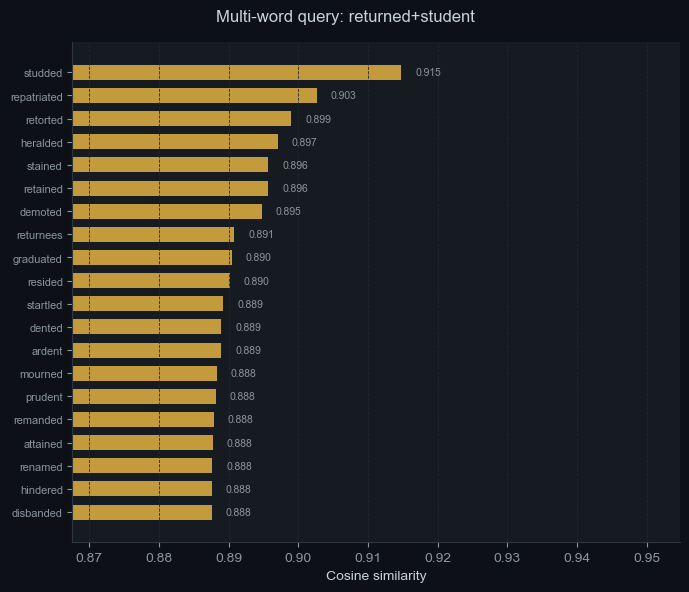

Saved → viz4_multiword_bar.png


In [6]:
model = load_facebook_vectors("/enp_embeddings/toastynews.bin")
phrase = ["returned", "student"]
valid_phrase = [w for w in phrase if w in model]

if valid_phrase:
    results = model.most_similar(positive=valid_phrase, topn=20)
    terms_mw, scores_mw = zip(*results)

    fig, ax = plt.subplots(figsize=(7, 6))
    fig.suptitle(f'Multi-word query: {"+".join(valid_phrase)}', fontsize=12)

    bars = ax.barh(list(terms_mw)[::-1], list(scores_mw)[::-1],
                   color=PALETTE[3], alpha=0.85, height=0.65)
    for bar, val in zip(bars, list(scores_mw)[::-1]):
        ax.text(bar.get_width() + 0.002, bar.get_y() + bar.get_height() / 2,
                f"{val:.3f}", va="center", ha="left", fontsize=7.5, color="#8b949e")

    ax.set_xlabel("Cosine similarity")
    ax.set_xlim(min(scores_mw) - 0.02, max(scores_mw) + 0.04)
    ax.grid(axis="x", linestyle="--")
    ax.tick_params(axis="y", labelsize=8)
    ax.spines[["top", "right"]].set_visible(False)

    plt.tight_layout()
    plt.savefig("viz4_multiword_bar.png", dpi=150, bbox_inches="tight",
                facecolor=fig.get_facecolor())
    plt.show()
    print("Saved → viz4_multiword_bar.png")
else:
    print("None of the phrase words are in the vocabulary.")